<a href="https://colab.research.google.com/github/hindhammad24/Final-Assignment/blob/main/iat461_final_assiment_checkpoint2_hindhammad_301580180.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# iAT 461 / 882  - Final Assignment
## Poké Pulls TCG : Pokémon Card Price Analysis

**Name:** `[Hind Hesham Hammad]`

**SFU ID:** `[301580180]`

**Date:** `[01/07/2026]`

**Client:** `[Ryan Ng]`  



## Project Overview

Poké Pulls TCG wants to better understand what factors influence Pokémon card market prices.
The goal of this project is to analyze card characteristics and identify patterns that may help estimate the value of individual cards.

instead of manually judging every card based only on experience, this project explores whether information already available about each card can provide useful insights into its market value.

From a business perspective, understanding these patterns can help Poké Pulls make more informed decisions when evaluating cards and identifying potentially valuable cards.

From a data science perspective, this project begins with exploratory data analysis (EDA) to understand the dataset, identify important features, detect possible data issues, and determine whether the available information is suitable for future predictive modeling.

# Checkpoint 1 - Exploratory Data Analysis

### initial Setup

In [ ]:
# import libraries needed for data exploration and visualization

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully")

Libraries imported successfully


### Dataset Overview

In [ ]:
# Load the Pokémon card price dataset

df = pd.read_csv("pokemon_card_prices.csv")

# Display first few rows
df.head()

,name,set,series,release_date,rarity,supertype,subtypes,types,hp,artist,market_price_usd
0,Scatterbug,Scarlet & Violet,Scarlet & Violet,2023/03/31,Common,Pokémon,Basic,Grass,30,sowsow,0.17
1,Pineco,Scarlet & Violet,Scarlet & Violet,2023/03/31,Common,Pokémon,Basic,Grass,60,Shigenori Negishi,0.12
2,Cacturne,Scarlet & Violet,Scarlet & Violet,2023/03/31,Uncommon,Pokémon,Stage 1,Grass,130,DOM,0.21
3,Gogoat,Scarlet & Violet,Scarlet & Violet,2023/03/31,Common,Pokémon,Stage 1,Grass,130,Gemi,0.14
4,Sprigatito,Scarlet & Violet,Scarlet & Violet,2023/03/31,Common,Pokémon,Basic,Grass,70,Saya Tsuruta,0.27


In [ ]:
# Check dataset size

df.shape

(1000, 11)

In [ ]:
# Display column names

df.columns

Index(['name', 'set', 'series', 'release_date', 'rarity', 'supertype',
       'subtypes', 'types', 'hp', 'artist', 'market_price_usd'],
      dtype='object')

In [ ]:
# Check data types and missing values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              1000 non-null   object 
 1   set               1000 non-null   object 
 2   series            1000 non-null   object 
 3   release_date      1000 non-null   object 
 4   rarity            1000 non-null   object 
 5   supertype         1000 non-null   object 
 6   subtypes          1000 non-null   object 
 7   types             1000 non-null   object 
 8   hp                1000 non-null   int64  
 9   artist            1000 non-null   object 
 10  market_price_usd  1000 non-null   float64
dtypes: float64(1), int64(1), object(9)
memory usage: 86.1+ KB


In [ ]:
# Basic numerical summary

df.describe()

,hp,market_price_usd
count,1000.000000,1000.000000
mean,120.840000,5.390110
std,67.766413,31.211284
min,30.000000,0.020000
25%,70.000000,0.150000
50%,100.000000,0.270000
75%,140.000000,0.872500
max,340.000000,580.920000


#### initial Dataset Findings

The dataset contains **1,000 Pokémon cards with 11 features**. Each row represents one individual Pokémon card, including information about its identity, release details, characteristics, and market value.

The available features include both categorical and numerical information. Categorical features include details such as card set, series, rarity, type, subtype, and artist. Numerical features include HP and the target variable, market price in USD.

The target variable for future prediction is **market_price_usd**, which represents the current market value of each card. Since this variable contains continuous numerical values, the future modeling stage will likely focus on a regression approach.

From the client's perspective, the dataset provides several possible factors that may influence card value, such as rarity, release information, and card characteristics.

From a data science perspective, the dataset appears suitable for further analysis because it contains a mixture of categorical and numerical variables. However, most variables are stored as categorical text values, meaning feature encoding will likely be required before building predictive models.

### Data Quality Check

#### Missing Values

Missing values can affect analysis and future prediction models because some algorithms cannot directly process incomplete records. Understanding the quality of the dataset helps determine whether cleaning steps are necessary.

In [ ]:
# Check the number of missing values in each column

df.isnull().sum()

,0
name,0
set,0
series,0
release_date,0
rarity,0
supertype,0
subtypes,0
types,0
hp,0
artist,0


##### Missing Values Findings

The missing value check shows that **all 11 columns contain 1,000 non-null values**, meaning there are no missing entries in the dataset.

This means no rows need to be removed or filled with estimated values during the initial cleaning stage.

From the client's perspective, this is useful because all available card information can be considered during the analysis without losing observations.

From a data science perspective, the absence of missing values allows the exploration phase to continue without requiring imputation methods. However, further checks are still required to identify issues such as duplicate records, unusual values, or highly skewed variables.

#### Duplicate Records Check

Duplicate rows can create bias during analysis because the same card information would be counted multiple times.

In [ ]:
# Check duplicate rows

df.duplicated().sum()

np.int64(0)

##### Duplicate Records Findings

The duplicate records check found **0 duplicated rows** in the dataset.

This indicates that each row represents a unique Pokémon card observation, preventing repeated cards from influencing the analysis.

For the client, this increases confidence that the price patterns discovered later are based on individual cards rather than repeated records.

From a data science perspective, no duplicate removal is required before continuing with exploratory data analysis.

#### Additional Data Quality Checks


##### Checking for Negative Values

Negative values would represent invalid data for some features.

For example:
- Pokémon HP cannot be negative.
- Market price cannot be negative.

This check identifies whether any numerical columns contain impossible negative values.

In [ ]:
# Check negative values in numerical columns

numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

negative_values = (df[numeric_columns] < 0).sum()

negative_values

,0
hp,0
market_price_usd,0


###### Finding

No negative values were found in the numerical features.

This means all numerical measurements fall within valid ranges, so no correction is required.

##### checking for Zero Values

Some variables should not contain zero values because zero would represent an impossible observation.

For this dataset:
- HP = 0 would represent an invalid card.
- Market price = 0 would represent a card with no value.

This check helps identify potentially incorrect records.

In [ ]:
# Check zero values in important numerical columns

zero_values = (df[numeric_columns] == 0).sum()

zero_values

,0
hp,0
market_price_usd,0


###### Finding

No zero values were found in the checked numerical features.

All cards contain valid HP and market price information.

##### Checking Numerical Ranges

Summary statistics were examined to identify unusual values or possible outliers.

The minimum, median, average, and maximum values help determine whether numerical features have realistic ranges.

In [ ]:
# Display numerical summary statistics

df[numeric_columns].describe()

,hp,market_price_usd
count,1000.000000,1000.000000
mean,120.840000,5.390110
std,67.766413,31.211284
min,30.000000,0.020000
25%,70.000000,0.150000
50%,100.000000,0.270000
75%,140.000000,0.872500
max,340.000000,580.920000


###### Finding

The numerical ranges appear reasonable.

HP values fall within expected Pokémon card ranges.

The market price variable contains very large differences between the median and maximum value. This suggests the presence of expensive collectible cards.

These values are not removed because high-value cards are expected in collectible markets. instead, the price distribution will be investigated during exploratory analysis.

##### Checking Date Validity

The release date column was checked to ensure that all values can be correctly interpreted as dates.

invalid dates could affect time-based analysis.

In [ ]:
# Convert release date to datetime format

df['release_date'] = pd.to_datetime(
    df['release_date'],
    errors='coerce'
)

# Count invalid dates

invalid_dates = df['release_date'].isna().sum()

invalid_dates

np.int64(0)

###### Finding

No invalid dates were found.

All release dates were successfully converted into datetime format.

##### Checking Empty Text Values

Missing values do not always appear as NaN.

Some datasets contain empty strings ("") instead.

This check identifies blank text entries that could affect categorical analysis.

In [ ]:
# Check empty strings in object columns

text_columns = df.select_dtypes(include='object').columns

empty_strings = (
    df[text_columns]
    .apply(lambda x: (x == "").sum())
)

empty_strings

,0
name,0
set,0
series,0
rarity,0
supertype,0
subtypes,0
types,0
artist,0


##### Finding

No empty text values were found.

All categorical fields contain valid text entries.

##### Checking Category Consistency

Categorical features were examined to identify unexpected values or columns with no variation.

Features with only one unique value provide no useful information for modelling.

In [ ]:
# Count unique values in categorical columns

categorical_columns = df.select_dtypes(include='object').columns

unique_categories = df[categorical_columns].nunique()

unique_categories

,0
name,620
set,10
series,2
rarity,16
supertype,1
subtypes,13
types,10
artist,131


###### Finding

Most categorical features contain multiple meaningful categories.

However, the `supertype` column contains only one unique value:

"Pokémon"

Since this feature has no variation, it does not provide useful information for analysis or prediction and may be removed during feature selection.

#### Data Quality Check Summary

After performing additional validation checks:


1. Missing values = No missing values found
2. Duplicate rows = No duplicate rows found
3. Negative values = None detected
4. Zero values = None detected
5. invalid dates = None detected
6. Empty text values = None detected
7. Unrealistic numerical ranges = None detected
8. Price outliers = Present and will be investigated
9. Constant features = supertype contains one unique value

Overall, the dataset appears clean.

The only issue requiring further investigation is the skewed distribution of market prices caused by high-value collectible cards.

## Exploratory Data Analysis (EDA)

### Numerical EDA

After completing the data quality checks, exploratory data analysis was performed to understand the main patterns and relationships within the dataset.

The main focus is the market price variable because it represents the value we want to understand and potentially predict.


#### Dataset Overview

Before visualizing the variables, basic statistics were reviewed to understand the scale and distribution of numerical features.

In [ ]:
df.describe()

,release_date,hp,market_price_usd
count,1000,1000.000000,1000.000000
mean,2021-11-27 06:17:16.799999744,120.840000,5.390110
min,2019-11-15 00:00:00,30.000000,0.020000
25%,2020-05-01 00:00:00,70.000000,0.150000
50%,2021-12-07 12:00:00,100.000000,0.270000
75%,2023-06-09 00:00:00,140.000000,0.872500
max,2023-08-11 00:00:00,340.000000,580.920000
std,NaN,67.766413,31.211284


##### Observation

The dataset contains 1,000 Pokémon cards.

The market price has a mean of **$5.39**, while the median price is only **$0.27**. This large difference shows that the distribution is strongly affected by a small number of expensive cards.

The minimum market price is **$0.02**, while the maximum price reaches **$580.92**, showing a very large range between typical cards and rare high-value cards.

The standard deviation of **$31.21** is also much larger than the median price, which indicates high variation in card values.

Because collectible cards often contain a small number of extremely valuable items, this suggests the market price distribution may be heavily right-skewed.

#### Market Price Distribution

A histogram was created to visualize how market prices are distributed.

This helps determine whether the target variable follows a normal distribution or requires transformation.

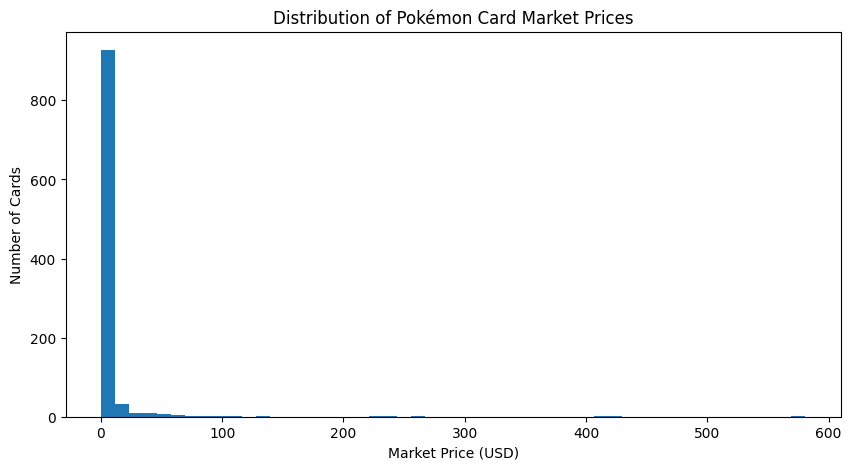

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(df['market_price_usd'], bins=50)
plt.xlabel("Market Price (USD)")
plt.ylabel("Number of Cards")
plt.title("Distribution of Pokémon Card Market Prices")

plt.show()


##### Observation

The market price distribution is highly right-skewed.

The histogram shows that the majority of Pokémon cards are concentrated at lower price values, while only a small number of cards reach much higher prices.

This matches the earlier summary statistics, where the median price was **$0.27** compared to the mean price of **$5.39** and the maximum price of **$580.92**.

From the client's perspective, this shows that most cards have relatively low market values, but a small number of rare and expensive cards can significantly affect the overall pricing landscape.

From a data science perspective, this indicates that market price contains extreme values that may influence future prediction models. instead of removing these cards, they should be investigated further because they likely represent meaningful high-value collectibles rather than incorrect data.

#### Log Transformation of Market Price

Because market price contains extreme high-value cards, a log transformation was applied to reduce skewness and make patterns easier to observe.

The transformation does not remove expensive cards; it compresses their scale.

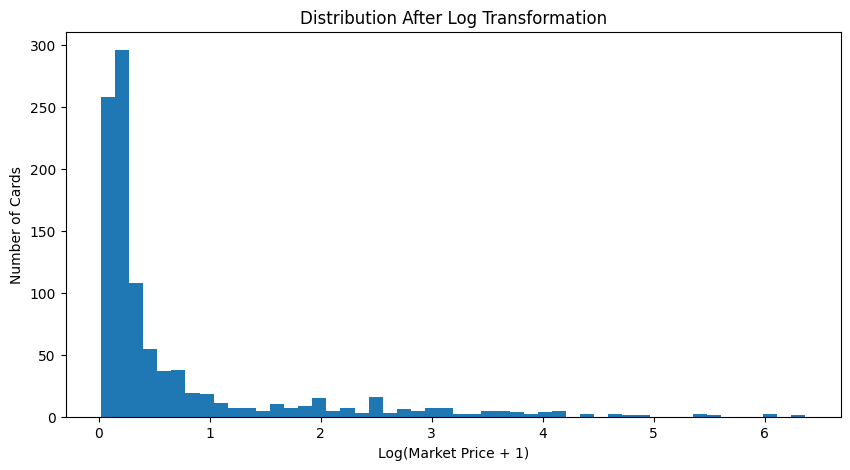

In [ ]:
import numpy as np
df['log_market_price'] = np.log1p(df['market_price_usd'])

plt.figure(figsize=(10,5))

plt.hist(df['log_market_price'], bins=50)

plt.xlabel("Log(Market Price + 1)")
plt.ylabel("Number of Cards")
plt.title("Distribution After Log Transformation")

plt.show()

##### Observation

After applying a log transformation to the market price, the distribution becomes easier to interpret because extremely expensive cards are compressed closer to the rest of the dataset.

The transformation does not remove high-value cards; instead, it reduces their influence on the visualization and future modelling process.

From the client's perspective, this shows that Pokémon card prices naturally contain large differences between common cards and rare collectibles.

From a data science perspective, the transformed price variable may be useful for future prediction models because it reduces the impact of extreme values while keeping important information about expensive cards.

#### Comparing Mean and Median Market Price

The mean and median were compared because a large difference between them indicates skewness caused by extreme values.

In [ ]:
mean_price = df['market_price_usd'].mean()
median_price = df['market_price_usd'].median()

print("Mean:", mean_price)
print("Median:", median_price)

Mean: 5.39011
Median: 0.27


##### Observation

The mean market price is $5.39, while the median market price is only $0.27.

This large difference indicates that the dataset is heavily influenced by a small number of high-value cards.

The median provides a better representation of a typical Pokémon card because most cards are closer to the lower price range, while a few expensive cards increase the overall average.

From the client's perspective, this highlights that most inventory consists of lower-priced cards, but rare high-value cards may require special attention when making pricing decisions.

From a data science perspective, this confirms that market price is not normally distributed and that outliers should be considered during feature engineering and model development.

#### Market Price by Rarity

Rarity is expected to influence card value because rare cards are usually more collectible.

The relationship between rarity categories and market price was explored.

<Figure size 1200x600 with 0 Axes>

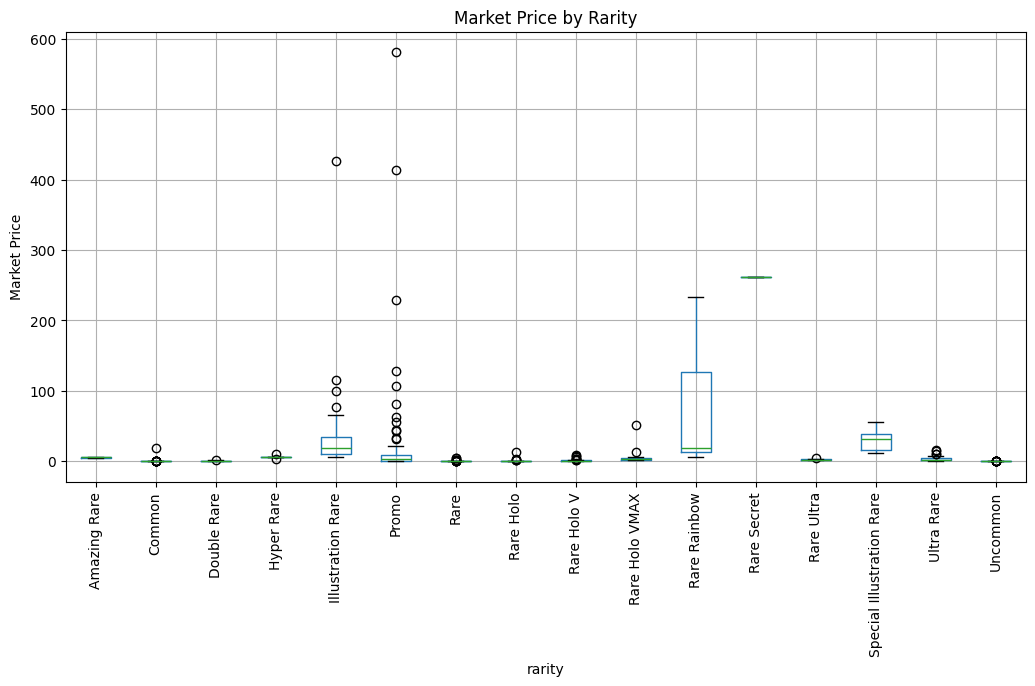

In [ ]:
plt.figure(figsize=(12,6))

df.boxplot(
    column='market_price_usd',
    by='rarity',
    rot=90,
    figsize=(12,6)
)

plt.title("Market Price by Rarity")
plt.suptitle("")

plt.ylabel("Market Price")

plt.show()

##### Observation

The boxplot shows that market prices vary significantly between different rarity categories.

Lower rarity categories, such as Common and Uncommon cards, generally have lower market prices, while some higher rarity categories show much larger price ranges.

Several rarity groups contain extreme outliers, especially Promo cards, where some cards reach very high market values compared to the typical cards in that category.

From the client's perspective, this suggests that rarity is an important factor when evaluating card value because certain rarity groups are more likely to contain expensive cards.

From a data science perspective, rarity appears to be an important feature for future prediction models. However, the presence of outliers within each category shows that rarity alone cannot completely explain price differences, meaning additional card features should also be investigated.

#### Numerical Feature Correlation

Correlation analysis was used to identify numerical variables that may have relationships with market price.

Correlation does not prove causation, but it helps identify useful features.

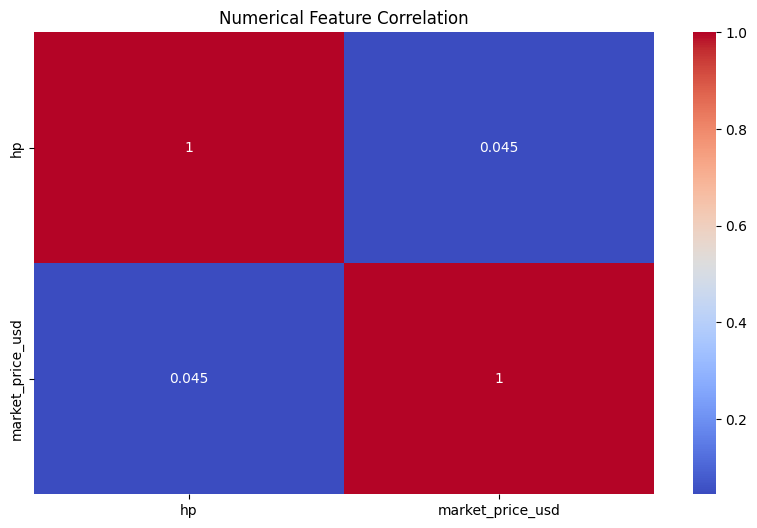

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(
    df[numeric_columns].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Numerical Feature Correlation")

plt.show()

##### Observation

The correlation analysis shows that HP has a very weak positive relationship with market price, with a correlation value of **0.045**.

This suggests that cards with higher HP do not necessarily have higher market values. While HP represents a gameplay characteristic of a Pokémon card, it does not appear to be an important factor when explaining price differences in this dataset.

From the client's perspective, this means that using HP alone would not be a reliable way to estimate card value.

From a data science perspective, HP may have limited predictive importance as a standalone numerical feature. However, it should not automatically be removed because other features, such as rarity, set, or card type, may interact with HP and provide additional information when combined in a model.

### Categorical EDA

#### Distribution of Card Rarity

Rarity is expected to influence market value because collectible cards are often priced based on scarcity.

Before analyzing its relationship with price, the distribution of rarity categories was examined to understand how many examples exist in each group.

This helps determine whether some rarity categories may have limited representation in the dataset.

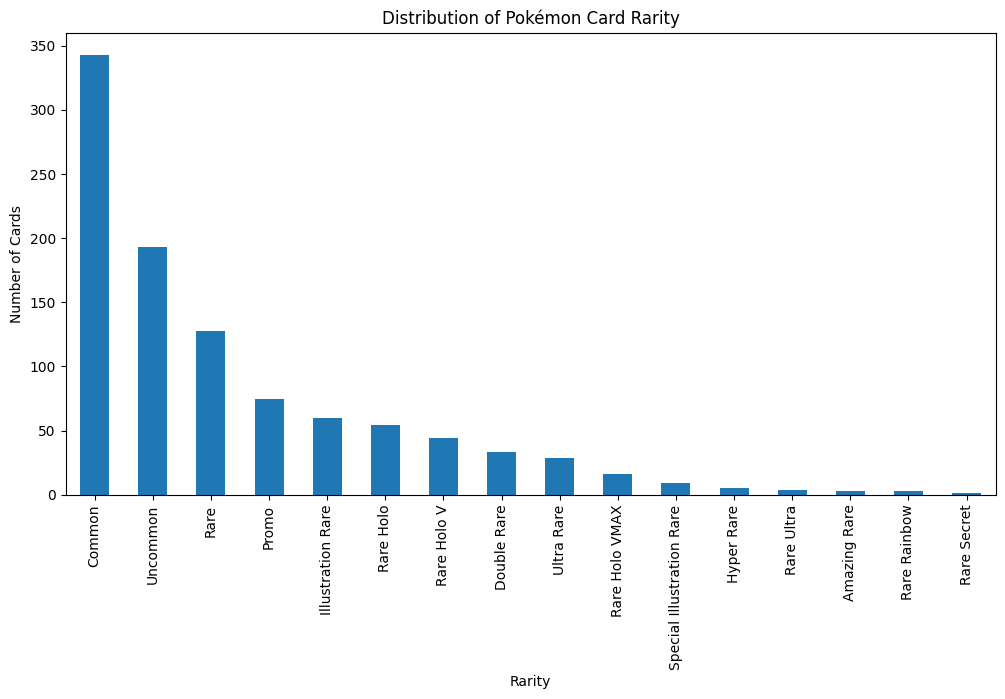

In [ ]:
plt.figure(figsize=(12,6))

df['rarity'].value_counts().plot(
    kind='bar'
)

plt.xlabel("Rarity")
plt.ylabel("Number of Cards")
plt.title("Distribution of Pokémon Card Rarity")

plt.xticks(rotation=90)

plt.show()

##### Observation

The rarity distribution is not evenly balanced across categories.

Common cards represent the largest portion of the dataset, followed by Uncommon and Rare cards. These categories contain many more examples compared to higher rarity categories.

Several premium rarity groups, such as Amazing Rare, Rare Rainbow, and Rare Secret, have very limited representation in the dataset.

From the client's perspective, this reflects the real collectible card market where common cards are widely available, while highly rare cards are much less frequent.

From a data science perspective, the imbalance between rarity categories should be considered during modelling. Categories with very few examples may have less reliable estimates because there is limited data available to learn their relationship with market price.

#### Market Price by Pokémon Set

The Pokémon set represents the expansion where a card was released.

Different sets may have different collector demand, availability, and historical importance, which can influence market price.

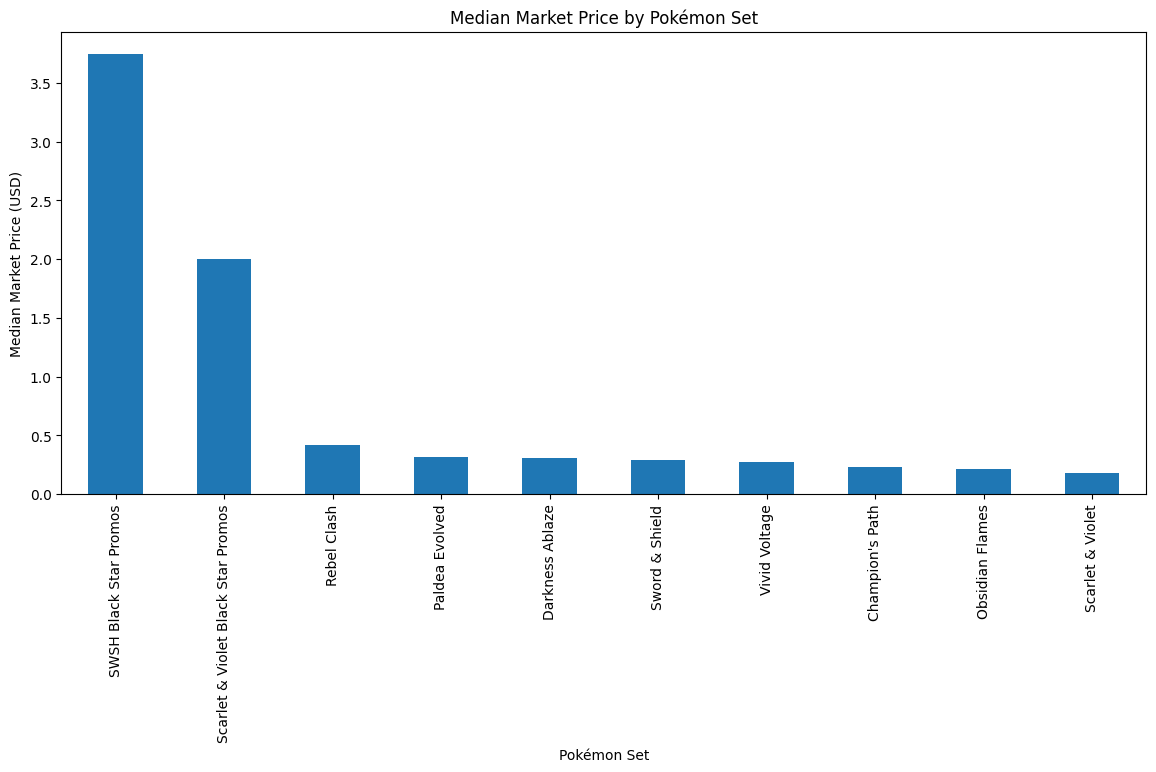

In [ ]:
plt.figure(figsize=(14,6))

df.groupby('set')['market_price_usd'].median().sort_values(ascending=False).plot(
    kind='bar'
)

plt.xlabel("Pokémon Set")
plt.ylabel("Median Market Price (USD)")
plt.title("Median Market Price by Pokémon Set")

plt.xticks(rotation=90)

plt.show()

##### Observation

The median market price varies significantly between Pokémon sets.

The highest median prices are found in promotional sets, especially **SWSH Black Star Promos** and **Scarlet & Violet Black Star Promos**, which have noticeably higher typical card values compared to the other sets in the dataset.

Most regular expansion sets have much lower median prices, suggesting that the set a card belongs to may influence its market value.

From the client's perspective, this indicates that the card's release set is an important factor to consider when evaluating inventory because some collections may contain generally higher-value cards.

From a data science perspective, the `set` feature appears to contain useful predictive information. However, the differences may also be affected by the types of cards included in each set, such as the number of rare or promotional cards, so additional features should be considered before drawing conclusions.

#### Market Price by Pokémon Type

The Pokémon type represents the category of the Pokémon featured on the card.

This analysis explores whether certain Pokémon types tend to have different market values. While type alone may not determine price, it can reveal patterns that may be useful for future modelling.

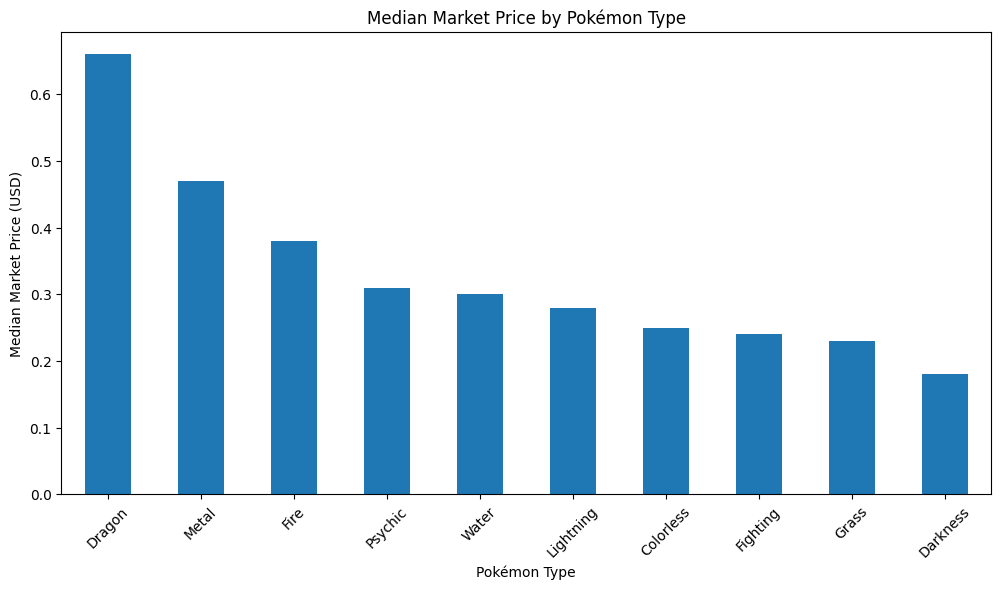

In [ ]:
plt.figure(figsize=(12,6))

df.groupby('types')['market_price_usd'].median().sort_values(ascending=False).plot(
    kind='bar'
)

plt.xlabel("Pokémon Type")
plt.ylabel("Median Market Price (USD)")
plt.title("Median Market Price by Pokémon Type")

plt.xticks(rotation=45)

plt.show()

##### Observation

The median market price varies between different Pokémon types, although the differences are smaller compared to factors such as rarity and set.

Dragon-type cards have the highest median market price in this dataset, followed by Metal and Fire types. Other types show relatively similar median values, with Darkness having the lowest median price among the categories shown.

From the client's perspective, this suggests that Pokémon type may provide some additional context when evaluating card value, but it is unlikely to be the main factor determining price.

From a data science perspective, type may contain some predictive information, but the weaker differences between categories suggest that it should be combined with stronger features such as rarity, set, and card characteristics rather than used as a standalone predictor.

### Temporal EDA

#### Market Price by Release Year

The release date may influence card value because older cards can have different levels of availability, collector interest, and market demand.

The release year was extracted from the release date to explore whether card prices vary across different release periods.

In [ ]:
# Convert release_date from string to datetime format

df['release_date'] = pd.to_datetime(df['release_date'])

# Check the new data type

df['release_date'].dtype

dtype('<M8[ns]')

##### Converting Release Date Format

The release date column was initially stored as text (object type), which prevents date-based analysis.

To analyze whether release timing affects market price, the column was converted into a datetime format. This allows extracting useful features such as release year.

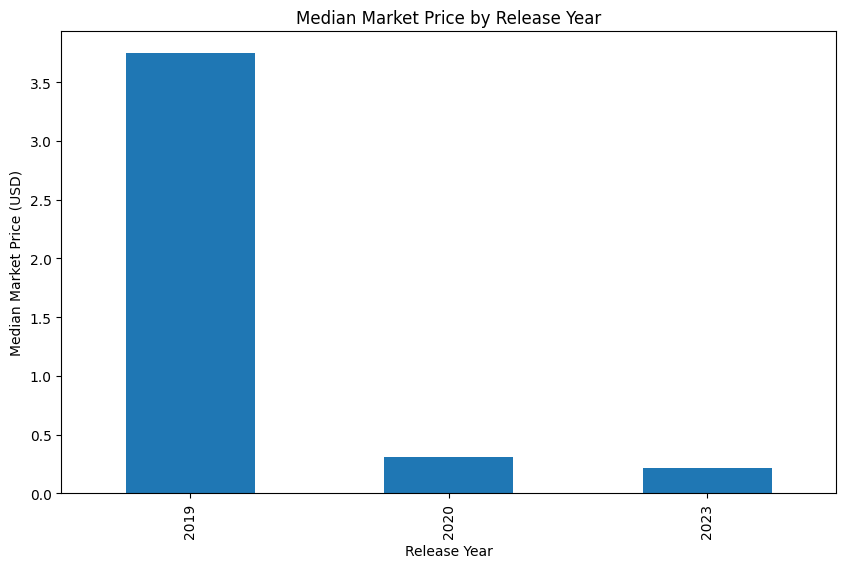

In [ ]:
# Extract release year

df['release_year'] = df['release_date'].dt.year

plt.figure(figsize=(10,6))

df.groupby('release_year')['market_price_usd'].median().plot(
    kind='bar'
)

plt.xlabel("Release Year")
plt.ylabel("Median Market Price (USD)")
plt.title("Median Market Price by Release Year")

plt.show()

##### Observation

The median market price varies considerably between different release years.

Cards released in 2019 have the highest median market price in the dataset, while cards from 2020 and 2023 show much lower typical values.

From the client's perspective, this suggests that release period may influence card value because older collections can have different levels of demand, availability, and collector interest.

From a data science perspective, release year may contain useful information for predicting market price. However, the dataset only contains a limited number of release years, so this relationship should be interpreted carefully because differences between years may also be caused by other factors such as rarity, set popularity, or the types of cards released during each period.

## EDA Findings Summary and Modelling Direction

The exploratory analysis shows that Pokémon card market price is influenced by multiple card characteristics rather than a single feature.

Rarity appears to be one of the strongest potential predictors because higher rarity categories generally represent fewer available cards and show differences in market value.

Other categorical features, including set, subtype, and Pokémon type, show differences in median prices and may provide additional information when combined with stronger predictors.

The analysis also shows that HP has a very weak relationship with market price, meaning gameplay statistics alone may not explain card value.

Release year may provide some useful information because different release periods show different median prices, although this relationship should be interpreted carefully because other factors such as rarity and set popularity may influence the difference.

Based on these findings, a supervised regression model is appropriate for the next phase because the goal is to predict a continuous outcome: market price in USD.

## Assumptions Log

During the exploratory analysis, several assumptions were made:

1. Market price is treated as the target variable because the goal is to estimate the monetary value of Pokémon cards.

2. Market price values are assumed to represent realistic market conditions. Extreme high-value cards are not removed because they may represent meaningful collector behaviour rather than errors.

3. Rarity categories are assumed to represent differences in card availability and collector demand.

4. Categorical variables such as rarity, Pokémon set, subtype, and type are assumed to contain useful information for predicting market value after encoding.

5. Release year is treated as a potential feature, but not as a direct indicator of value because age alone does not determine collector demand.

6. HP is included as a possible feature but is expected to have limited predictive value based on the correlation analysis.

## initial Approach Decision

The project is treated as a supervised learning regression problem.

The objective is to predict Pokémon card market price in USD using known card attributes. Since market price is a continuous numerical value, regression models are more appropriate than classification models.

Potential input features include:

- Card rarity
- Pokémon set
- Pokémon type
- Subtype
- Release year
- HP
- Other available card characteristics

The planned workflow is:

1. Perform feature engineering on categorical variables.
2. Split the dataset into training and testing sets.
3. Train regression models.
4. Evaluate model performance using appropriate regression metrics such as RMSE and R².
5. interpret which features contribute most to predicting card value.

The final model should provide a useful estimate of market price and help identify which card characteristics are most associated with higher collector value.

## Checkpoint 1 Progress Report

## Project Overview

This project focuses on predicting Pokémon card market prices using card characteristics from a structured dataset. The goal is to understand which features contribute to collector value and develop a model capable of estimating market price.

## Completed Work

The initial exploratory data analysis has been completed. The dataset was inspected for structure, missing values, duplicates, and data quality issues.

Several exploratory visualizations were created to understand relationships between card characteristics and market price, including:

- Market price distribution
- Log-transformed price distribution
- Price differences across rarity categories
- Median prices across Pokémon sets
- Median prices across Pokémon types
- Price trends by release year
- Correlation analysis between numerical features

## Main Findings

The analysis found that market price is highly uneven, with most cards having lower values and a small number of expensive cards creating a long right tail.

Rarity appears to be an important factor affecting card value, while numerical gameplay features such as HP show little relationship with price.

Different Pokémon sets and types also show differences in median prices, suggesting that multiple features should be considered together when building the prediction model.

# Peer Reviews

## Feedback i Provided to Ryan


Before moving into the modelling stage, i reviewed the feedback from my peer review exchange with Ryan. This feedback helped identify strengths in my exploratory analysis and areas that could be improved before building the prediction model.

The purpose of including this reflection is to show how the feedback influenced my modelling decisions and how i will apply suggestions during the feature engineering and model development stages.

Hey Ryan, i went through your EDA notebook.

i think you did a really good job. i like that you did not just jump into analysis but found that the data appears to be match level instead of player level although i dont really get the meaning of it. The aggregation step makes sense because the goal is to predict player market value.

You did a great job at the dataset cleaning section which was really detailed, also i liked that you verified the tournament totals instead of assuming they were correct  apologies i didnt notcie that in the dataset before i gave it to you.

The position based analysis was interesting because it shows that different positions should not always be compared the same way something i didnt think of honestly.

For the progress report  it clearly explains the project direction.

some suggestions or like my questions:
Since market value seems heavily skewed, i would consider adding a log transformation like i did in the Pokémon pricing analysis. This might help the model because a few extremely expensive players could dominate predictions.

i liked the position analysis. Maybe consider whether building separate models by position would make sense, because the statistics that define a valuable goalkeeper are very different from a forward.

for the synthetic dataset finding,  think this is actually one of your strongest findings. i would make sure this limitation is clearly mentioned later because it affects how confidently the model can be interpreted for real world scouting.

## Feedback i Received from Ryan

" i think Checkpoint 1 does a good job of building a strong foundation for the rest of the project. i really liked the extra emphasis on data quality checks. Checking for missing values, duplicate rows, negative and zero values, invalid dates, empty text values, and constant features made the analysis feel more thorough and gave me more confidence in knowing you will do a good job.

identifying that supertype only contains one value was a good find, as it was something that i did not know beforehand. it was also helpful that the analysis identified early on that most of the variables are categorical text values. Knowing that features such as rarity, set, type, subtype, and artist will require encoding gives a clear idea of what will need to be considered before building a prediction model.

Another positive exploration performed was investigating the market price distribution. The comparison between the mean price of $5.39 and median of $0.27 clearly showed how much a small number of expensive cards affect the data. i also liked that these high-value cards were not removed as outliers, since they may represent real valuable collectibles. The log transformation was a good follow-up because it provides a way to reduce the influence of the extreme prices while keeping those cards in the dataset.

One area that could be improved is expanding the comparisons between the different categorical features. Rarity was investigated and showed some useful patterns, but it would also be helpful to see if set, card type, subtype, or release period showed similar differences in price. For example, comparing the price distributions across sets could help determine whether certain sets are associated with higher-value cards.

Something that was missing was clearly stating if this problem was a supervised or unsupervised problem and justifying the reason. This was part of the deliverables for this checkpoint."

## My Understanding

Ryan reviewed my Pokémon card market price prediction project and provided feedback on my Checkpoint 1 analysis.

One of the main strengths he identified was the detailed data quality checking process. He noted that checking missing values, duplicate rows, invalid values, incorrect dates, empty text values, and constant features helped create a stronger foundation before moving into modelling.

This feedback reinforced the importance of completing data validation before training models. Since prediction models depend heavily on the quality of their input data, identifying these issues early helps prevent unreliable results later.

Ryan also highlighted the importance of identifying features that do not provide useful information. For example, discovering that supertype only contains one unique value was an important finding because this feature will not help the model distinguish between different cards.

Another important point from the feedback was the analysis of market price distribution. Ryan agreed that keeping high-value cards instead of removing them was the correct decision because these cards represent real collectible items rather than incorrect data. The log transformation approach was also supported because it reduces the impact of extreme prices while still preserving valuable cards in the dataset.

Ryan suggested expanding the comparison of categorical variables. While rarity showed strong differences in price, additional investigation into variables such as set, type, subtype, and release period could provide more information about factors influencing card value.

Finally, Ryan pointed out that the project should clearly identify the machine learning problem type. Since the goal is predicting a continuous market price value, this project is a supervised learning regression problem.

## How I Will Apply the Feedback

Based on my own EDA findings and Ryan's suggestions, I will make the following decisions: Continue with a supervised regression approach

The goal of this project is to predict market_price_usd, which is a continuous numerical value. Therefore, regression models are appropriate because the model will learn relationships between card characteristics and their market prices.

Keep high-value cards in the dataset

During the EDA stage, I observed that the market price distribution was highly right-skewed because a small number of expensive cards increased the average price. However, these cards were not removed because they represent meaningful examples in the collectible card market. Removing them could remove important information about valuable cards that the client may actually want to identify.Instead, I will investigate transformations such as log transformation to reduce the effect of extreme values during modelling.

Based on the feedback, I will carefully evaluate which card characteristics provide useful information for predicting market price. Features that provide little or no useful information, such as supertype, will be removed before modelling.

Instead of using the raw release date as text, I will transform it into meaningful numerical features.m This will allow the model to understand possible relationships between card age, release period, and market value.


# Technique Selection and Justification

Based on the project goal and the exploratory data analysis, the problem can be defined as a supervised learning regression problem.

The goal of the client is to estimate the market price of Pokémon cards using existing information about each card. Since the dataset already contains historical examples where each card has a known market price (market_price_usd), the model can learn patterns between card characteristics and their corresponding values.

The target variable for this project is: Market Price (USD)

The objective is to predict this continuous numerical value using features such as card rarity, set information, card type, subtype, release date, and other available characteristics.

## Client Perspective

From the client's perspective, the goal is to create a tool that can support collectible card shops when estimating card values.

Currently, pricing collectible cards can require manual research and experience because card value depends on many different factors. A prediction model could help provide a consistent estimate of market value based on information already available about the card.

The model could help the client:

- Quickly estimate the expected market value of cards.
- Identify cards that may be priced lower or higher than expected.
- Support better inventory and pricing decisions.

The goal is not to replace expert judgement, but to provide an additional data-driven tool that helps make pricing decisions more efficient.

## Data Scientist Perspective

From a data science perspective, this problem is suitable for supervised learning because:

- The dataset contains a defined target variable (market_price_usd).
- Each training example has known input features and a known output value.
- The goal is to predict a numerical outcome rather than discover unknown groups.

Because the target variable represents a continuous value, regression models are more appropriate than classification models.

A classification approach would require converting prices into categories such as "cheap", "medium", or "expensive", which would remove useful information from the original market values. Regression allows the model to predict the actual estimated price.

## Modelling Approach

The modelling process will begin with baseline regression models to understand how well the available card information can predict market price.

The main evaluation metrics will be:

- RMSE (Root Mean Squared Error): Measures the average prediction error while giving more importance to larger mistakes.
- MAE (Mean Absolute Error): Shows the average absolute difference between predicted and actual prices.
- R² (Coefficient of Determination): Measures how much variation in market price is explained by the model.

These metrics will help determine whether the model provides useful predictions for the client's pricing decisions.

## Initial Modelling Assumption

Based on the EDA findings, I expect that some card characteristics will have stronger relationships with market price than others.

For example:

- Rarity may provide important predictive information because rare cards often have higher collector demand.
- Set and series may influence value because certain releases are more desirable.
- Release date may capture differences between newer and older cards.
- HP may provide some information about card strength but may not be the main factor determining collectible value.

However, these relationships need to be tested through modelling rather than assumed based only on exploratory analysis.

## Limitations to Consider

Before building the model, several limitations should be considered:

- The dataset contains 1,000 cards, which may limit how well the model generalizes to all Pokémon cards.
- Market prices change over time based on collector demand and market trends.
- Important factors such as card condition, grading, popularity, and demand are not included in the dataset.
- Some categorical features contain many unique values, which may require careful feature engineering to avoid creating unnecessary complexity.

#Checkpoint 2 - Feature Engineering Decisions

## Reviewing Feature Structure

Before creating the prediction model, the original dataset needs to be prepared into a format that machine learning models can understand.

The first step is to review the structure of each feature, including the data types and number of unique values. This helps determine which variables contain useful information and which features may require transformation or removal before modelling.

Since the dataset contains a mixture of numerical and categorical information, this step will help decide how each feature should be handled during the feature engineering process.

In [ ]:
# Review dataset structure before feature engineering

# Display data types
print("Data Types:")
display(df.dtypes)

# Display number of unique values for each feature
print("\nNumber of Unique Values:")
display(df.nunique().sort_values())

# Display first few rows to review feature structure
print("\nDataset Preview:")
display(df.head())

Data Types:


,0
name,object
set,object
series,object
release_date,datetime64[ns]
rarity,object
supertype,object
subtypes,object
types,object
hp,int64
artist,object



Number of Unique Values:


,0
supertype,1
series,2
release_year,3
release_date,10
types,10
set,10
subtypes,13
rarity,16
hp,31
artist,131



Dataset Preview:


,name,set,series,release_date,rarity,supertype,subtypes,types,hp,artist,market_price_usd,log_market_price,release_year
0,Scatterbug,Scarlet & Violet,Scarlet & Violet,2023-03-31,Common,Pokémon,Basic,Grass,30,sowsow,0.17,0.157004,2023
1,Pineco,Scarlet & Violet,Scarlet & Violet,2023-03-31,Common,Pokémon,Basic,Grass,60,Shigenori Negishi,0.12,0.113329,2023
2,Cacturne,Scarlet & Violet,Scarlet & Violet,2023-03-31,Uncommon,Pokémon,Stage 1,Grass,130,DOM,0.21,0.190620,2023
3,Gogoat,Scarlet & Violet,Scarlet & Violet,2023-03-31,Common,Pokémon,Stage 1,Grass,130,Gemi,0.14,0.131028,2023
4,Sprigatito,Scarlet & Violet,Scarlet & Violet,2023-03-31,Common,Pokémon,Basic,Grass,70,Saya Tsuruta,0.27,0.239017,2023



### observations

The feature inspection shows that the dataset contains a combination of numerical, categorical, and date-based information that will require different preparation steps before modelling.

The dataset contains:
1. Categorical features:
name
set
series
rarity
supertype
subtypes
types
artist

2. Numerical features:
hp
market_price_usd
log_market_price
Date features:
release_date
release_year

3. The target variable remains: market_price_usd

The additional feature log_market_price was created during the EDA stage to address the strong right-skew observed in market prices. This transformation will be considered during modelling because it reduces the influence of extremely expensive cards while keeping those valuable examples in the dataset.

#### Categorical Feature Analysis

The number of unique values shows that some categorical variables contain a small number of categories, while others contain many unique values.

For example:

rarity contains 16 unique categories.
subtypes contains 13 unique categories.
types contains 10 unique categories.
set contains 10 unique categories.
artist contains 131 unique categories.
name contains 620 unique categories.

This indicates that different categorical features will need different considerations before encoding.


From the client's perspective, the model should use card characteristics that reflect real factors affecting collectible value. Features such as rarity, set, and card type may help estimate value because collectors often consider these characteristics when evaluating cards.

However, using information that is too specific, such as individual card names, may make the model less useful when estimating prices for new or unseen cards.


From a data science perspective, categorical variables with many unique values can create a large number of features after encoding. This can increase model complexity and may cause the model to memorize individual examples instead of learning general pricing patterns.

Therefore, features such as name and artist require further evaluation before being included in the final model.

#### Constant Feature Detection

The feature inspection showed that: supertype contains only 1 unique value.

Since all cards have the same value for this feature, it does not provide any information that can help the model distinguish between different market prices.

For the client, including a feature that is identical for every card would not improve pricing predictions because it does not explain why some cards are more valuable than others.

A feature with no variation cannot contribute useful predictive information to a regression model. Removing constant features reduces unnecessary complexity and keeps the model focused on meaningful variables.

#### Initial Feature Engineering Decisions

- name: likely remove	High number of unique values may cause overfitting
set	Keep	May represent differences in collector demand
- series:	Represents broader release information
- release_date:	Transform	Convert date information into useful numerical features
- release_year:	captures release period differences
- rarity:	Potentially strong predictor of value
- supertype	Remove	Contains only one unique value
- subtypes:	May represent card characteristics
- types:	May influence collector interest
- hp:	Numerical gameplay characteristic
- artist:	May contain useful information but has many categories

## Selecting and Transforming Features


Based on the previous analysis, some features need to be removed, while others need to be converted into a format that machine learning models can understand.

In this step:

- Remove features with no predictive value.
- Transform date information into useful numerical features.
- Keep features that may influence Pokémon card value.

In [ ]:
# Create a copy for modelling preparation

model_df = df.copy()

# Remove constant feature
model_df = model_df.drop(columns=["supertype"])

# Check remaining columns
model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   name              1000 non-null   object        
 1   set               1000 non-null   object        
 2   series            1000 non-null   object        
 3   release_date      1000 non-null   datetime64[ns]
 4   rarity            1000 non-null   object        
 5   subtypes          1000 non-null   object        
 6   types             1000 non-null   object        
 7   hp                1000 non-null   int64         
 8   artist            1000 non-null   object        
 9   market_price_usd  1000 non-null   float64       
 10  log_market_price  1000 non-null   float64       
 11  release_year      1000 non-null   int32         
dtypes: datetime64[ns](1), float64(2), int32(1), int64(1), object(7)
memory usage: 90.0+ KB


## Evaluating High-Cardinality Features



Before encoding categorical variables, I need to evaluate features that contain many unique categories.

The previous feature analysis showed that `name` and `artist` contain many unique values. These features may contain useful information, but including them directly could increase model complexity and risk overfitting.

In this step, I will check how frequently these categories appear to decide whether they should be included in the final model.

In [ ]:
# Check frequency of high-cardinality features

print("Number of unique card names:")
print(model_df["name"].nunique())

print("\nMost common card names:")
display(model_df["name"].value_counts().head(10))


print("\nNumber of unique artists:")
print(model_df["artist"].nunique())

print("\nMost common artists:")
display(model_df["artist"].value_counts().head(10))

Number of unique card names:
620

Most common card names:


,count
name,
Tinkatink,5
Greavard,5
Tandemaus,4
Tadbulb,4
Capsakid,4
Growlithe,4
Rockruff,4
Riolu,4
Koraidon ex,4



Number of unique artists:
131

Most common artists:


,count
artist,
5ban Graphics,74
Kouki Saitou,45
Shin Nagasawa,35
aky CG Works,25
nagimiso,25
Akira Komayama,21
Mizue,21
Saya Tsuruta,18
Anesaki Dynamic,18


#### Observations

The analysis shows that `name` and `artist` have different levels of usefulness for modelling.

- The `name` feature contains 620 unique values across 1,000 cards. Most card names only appear a small number of times, meaning this feature may cause the model to learn specific cards rather than general patterns that apply to new cards.

- The `artist` feature contains 131 unique values. Unlike card names, some artists appear frequently across multiple cards, which means this feature may contain useful information about patterns in card value.

From the client's perspective, the model should help estimate prices for different cards based on general characteristics. Using individual card names may make the model less useful when evaluating cards it has not seen before Artwork can influence collector interest, so keeping artist information may provide additional value when estimating market price.

From a data science perspective, `name` has very high cardinality compared to the dataset size, increasing the risk of overfitting after encoding. The `artist` feature has enough repeated categories to potentially provide predictive value, so it will be kept and evaluated during modelling.

Based on this analysis:

- `name` will be removed.
- `artist` will be kept and transformed during categorical encoding.

In [ ]:
# Remove name because of high cardinality

model_df = model_df.drop(columns=["name"])

# Check remaining features

model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   set               1000 non-null   object        
 1   series            1000 non-null   object        
 2   release_date      1000 non-null   datetime64[ns]
 3   rarity            1000 non-null   object        
 4   subtypes          1000 non-null   object        
 5   types             1000 non-null   object        
 6   hp                1000 non-null   int64         
 7   artist            1000 non-null   object        
 8   market_price_usd  1000 non-null   float64       
 9   log_market_price  1000 non-null   float64       
 10  release_year      1000 non-null   int32         
dtypes: datetime64[ns](1), float64(2), int32(1), int64(1), object(6)
memory usage: 82.2+ KB


## Transforming Release Date



The `release_date` feature contains the exact date when each Pokémon card was released.

Although release timing may influence collectible value, machine learning models cannot directly use datetime values. Therefore, the date information needs to be converted into a numerical feature.

During the EDA stage, `release_year` was created to represent the release period of each card. This feature will be used instead of the original date because it keeps the relevant information while making it easier for the model to interpret.

From the client's perspective, release period may help estimate value because older or newer card releases can have different levels of collector demand.

From a data science perspective, converting dates into numerical features allows regression models to identify relationships between release timing and market price.

In [ ]:
# Remove original datetime feature after extracting release_year

model_df = model_df.drop(columns=["release_date"])

# Check updated feature structure

model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   set               1000 non-null   object 
 1   series            1000 non-null   object 
 2   rarity            1000 non-null   object 
 3   subtypes          1000 non-null   object 
 4   types             1000 non-null   object 
 5   hp                1000 non-null   int64  
 6   artist            1000 non-null   object 
 7   market_price_usd  1000 non-null   float64
 8   log_market_price  1000 non-null   float64
 9   release_year      1000 non-null   int32  
dtypes: float64(2), int32(1), int64(1), object(6)
memory usage: 74.3+ KB


## Encoding Categorical Variables



The remaining dataset contains several categorical features that cannot be directly used by regression models.

These features need to be converted into numerical values while keeping the information they provide.

The categorical features being transformed are:

- set
- series
- rarity
- subtypes
- types
- artist

One-hot encoding will be used because these categories do not have a natural ranking. Instead of assigning numbers that could create false relationships, each category will be represented as a separate feature.

From the client's perspective, this allows the model to consider different card characteristics, such as rarity or release set, when estimating market value.

From a data science perspective, one-hot encoding is appropriate for categorical variables because it allows models to use category information without assuming an incorrect numerical relationship between categories.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Separate categorical columns
categorical_features = [
    "set",
    "series",
    "rarity",
    "subtypes",
    "types",
    "artist"
]

# Create encoder
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

# Fit and transform categorical features
encoded_features = encoder.fit_transform(model_df[categorical_features])

# Convert encoded features into dataframe
encoded_df = pd.DataFrame(
    encoded_features,
    columns=encoder.get_feature_names_out(categorical_features)
)

# Check encoded features
encoded_df.head()

,set_Champion's Path,set_Darkness Ablaze,set_Obsidian Flames,set_Paldea Evolved,set_Rebel Clash,set_SWSH Black Star Promos,set_Scarlet & Violet,set_Scarlet & Violet Black Star Promos,set_Sword & Shield,set_Vivid Voltage,series_Scarlet & Violet,series_Sword & Shield,rarity_Amazing Rare,rarity_Common,rarity_Double Rare,rarity_Hyper Rare,rarity_Illustration Rare,rarity_Promo,rarity_Rare,rarity_Rare Holo,rarity_Rare Holo V,rarity_Rare Holo VMAX,rarity_Rare Rainbow,rarity_Rare Secret,rarity_Rare Ultra,rarity_Special Illustration Rare,rarity_Ultra Rare,rarity_Uncommon,subtypes_Basic,"subtypes_Basic, Tera, ex","subtypes_Basic, V","subtypes_Basic, ex","subtypes_Basic, ex, Tera",subtypes_Stage 1,"subtypes_Stage 1, Tera, ex","subtypes_Stage 1, ex","subtypes_Stage 1, ex, Tera",subtypes_Stage 2,"subtypes_Stage 2, ex","subtypes_Stage 2, ex, Tera",subtypes_VMAX,types_Colorless,types_Darkness,types_Dragon,types_Fighting,types_Fire,types_Grass,types_Lightning,types_Metal,types_Psychic,types_Water,artist_0313,artist_5ban Graphics,artist_AKIRA EGAWA,artist_Akira Komayama,artist_Amelicart,artist_Anesaki Dynamic,artist_Asako Ito,artist_Atsuko Nishida,artist_Atsushi Furusawa,artist_Atsuya Uki,artist_Aya Kusube,artist_Ayaka Yoshida,artist_Cona Nitanda,artist_DOM,artist_Eri Yamaki,artist_Eske Yoshinob,artist_GIDORA,artist_GOSSAN,artist_Gemi,artist_HYOGONOSUKE,artist_Haru Akasaka,artist_Hasegawa Saki,artist_Hasuno,artist_Hideki Ishikawa,artist_Hitoshi Ariga,artist_Jerky,artist_Jiro Sasumo,artist_Jumpei Akasaka,artist_KEIICHIRO ITO,artist_KIYOTAKA OSHIYAMA,artist_KYUPIYAMA,artist_Kagemaru Himeno,artist_Kazuma Koda,artist_Kouki Saitou,artist_Kurata So,artist_Kyoko Umemoto,artist_Lee HyunJung,artist_MAHOU,artist_Masakazu Fukuda,artist_Masako Tomii,artist_Megumi Higuchi,artist_Megumi Mizutani,artist_Midori Harada,artist_Miki Tanaka,artist_Mina Nakai,artist_Misa Tsutsui,artist_Mitsuhiro Arita,artist_Mizue,artist_Motofumi Fujiwara,artist_N-DESIGN Inc.,artist_NC Empire,artist_Nagomi Nijo,artist_Naoki Saito,artist_Naoyo Kimura,artist_Narumi Sato,artist_Natsumi Yoshida,artist_Nelnal,artist_Nisota Niso,artist_Nobuhiro Imagawa,artist_Nurikabe,artist_OKACHEKE,artist_OKUBO,artist_Oswaldo KATO,artist_PLANETA Hiiragi,artist_PLANETA Igarashi,artist_PLANETA Mochizuki,artist_PLANETA Tsuji,artist_PLANETA Yamashita,artist_Pani Kobayashi,artist_Po-Suzuki,artist_Ryota Murayama,artist_Ryuta Fuse,artist_SATOSHI NAKAI,artist_SIE NANAHARA,artist_Saki Hayashiro,artist_Sanosuke Sakuma,artist_Satoshi Shirai,artist_Saya Tsuruta,artist_Scav,artist_Sekio,artist_Shiburingaru,artist_Shibuzoh.,artist_Shigenori Negishi,artist_Shin Nagasawa,artist_Shinji Kanda,artist_Shinya Komatsu,artist_Souichirou Gunjima,artist_Sumiyoshi Kizuki,artist_Suwama Chiaki,artist_TOKIYA,artist_Taira Akitsu,artist_Teeziro,artist_Tetsu Kayama,artist_The Pokémon Company Art Team,artist_Tika Matsuno,artist_Tomokazu Komiya,artist_Tonji Matsuno,artist_Toshinao Aoki,artist_Uta,artist_Yoshioka,artist_You Iribi,artist_Yuka Morii,artist_Yukiko Baba,artist_Yumi,artist_Yuu Nishida,artist_Yuya Oka,artist_aky CG Works,artist_aoki,artist_chibi,artist_hatachu,artist_hncl,artist_kanahei,artist_kantaro,artist_kawayoo,artist_kirisAki,artist_kodama,artist_kurumitsu,artist_matazo,artist_miki kudo,artist_nagimiso,artist_otumami,artist_ryoma uratsuka,artist_saino misaki,artist_so-taro,artist_sowsow,artist_sui,artist_takuyoa,artist_tetsuya koizumi,artist_toriyufu,artist_yuu,artist_zig
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0

### Observations

The categorical features were successfully converted into numerical features using one-hot encoding.

The original text-based categories:

- set
- series
- rarity
- subtypes
- types
- artist

were transformed into separate binary columns where:

- 1 represents that a card belongs to that category.
- 0 represents that it does not.

This allows regression models to use categorical information while avoiding incorrect assumptions about category order.

From the client's perspective, this allows the model to consider different card characteristics that may influence value, such as rarity, card set, and artwork style.These features provide the model with more information when estimating market price.


From a data science perspective, one-hot encoding is appropriate because these variables are categorical and do not have a natural ranking. The transformation converts non-numerical information into a format that regression algorithms can process while preserving the original category information.

## Preparing the Final Modelling Dataset



After transforming the categorical variables, the next step is to combine them with the remaining numerical features.

The final feature set will include:

- Encoded categorical variables
- HP
- Release year

The target variable will remain:

**market_price_usd**

The goal is to create:

- X: input features used by the model
- y: market price that the model will predict

From the client's perspective, this creates the final dataset that represents the information available when estimating a card's value.

From a data science perspective, separating features and target variables is required before training supervised learning models. This ensures the model learns relationships between input variables and the desired output.

In [ ]:
# Combine encoded categorical features with numerical features

numerical_features = model_df[
    [
        "hp",
        "release_year"
    ]
]

# Create final feature dataset
final_df = pd.concat(
    [
        numerical_features.reset_index(drop=True),
        encoded_df.reset_index(drop=True)
    ],
    axis=1
)

# Define X and y

X = final_df

y = model_df["market_price_usd"]

# Check final modelling data

print("Feature dataset shape:")
print(X.shape)

print("\nTarget variable shape:")
print(y.shape)

display(X.head())

Feature dataset shape:
(1000, 184)

Target variable shape:
(1000,)


,hp,release_year,set_Champion's Path,set_Darkness Ablaze,set_Obsidian Flames,set_Paldea Evolved,set_Rebel Clash,set_SWSH Black Star Promos,set_Scarlet & Violet,set_Scarlet & Violet Black Star Promos,set_Sword & Shield,set_Vivid Voltage,series_Scarlet & Violet,series_Sword & Shield,rarity_Amazing Rare,rarity_Common,rarity_Double Rare,rarity_Hyper Rare,rarity_Illustration Rare,rarity_Promo,rarity_Rare,rarity_Rare Holo,rarity_Rare Holo V,rarity_Rare Holo VMAX,rarity_Rare Rainbow,rarity_Rare Secret,rarity_Rare Ultra,rarity_Special Illustration Rare,rarity_Ultra Rare,rarity_Uncommon,subtypes_Basic,"subtypes_Basic, Tera, ex","subtypes_Basic, V","subtypes_Basic, ex","subtypes_Basic, ex, Tera",subtypes_Stage 1,"subtypes_Stage 1, Tera, ex","subtypes_Stage 1, ex","subtypes_Stage 1, ex, Tera",subtypes_Stage 2,"subtypes_Stage 2, ex","subtypes_Stage 2, ex, Tera",subtypes_VMAX,types_Colorless,types_Darkness,types_Dragon,types_Fighting,types_Fire,types_Grass,types_Lightning,types_Metal,types_Psychic,types_Water,artist_0313,artist_5ban Graphics,artist_AKIRA EGAWA,artist_Akira Komayama,artist_Amelicart,artist_Anesaki Dynamic,artist_Asako Ito,artist_Atsuko Nishida,artist_Atsushi Furusawa,artist_Atsuya Uki,artist_Aya Kusube,artist_Ayaka Yoshida,artist_Cona Nitanda,artist_DOM,artist_Eri Yamaki,artist_Eske Yoshinob,artist_GIDORA,artist_GOSSAN,artist_Gemi,artist_HYOGONOSUKE,artist_Haru Akasaka,artist_Hasegawa Saki,artist_Hasuno,artist_Hideki Ishikawa,artist_Hitoshi Ariga,artist_Jerky,artist_Jiro Sasumo,artist_Jumpei Akasaka,artist_KEIICHIRO ITO,artist_KIYOTAKA OSHIYAMA,artist_KYUPIYAMA,artist_Kagemaru Himeno,artist_Kazuma Koda,artist_Kouki Saitou,artist_Kurata So,artist_Kyoko Umemoto,artist_Lee HyunJung,artist_MAHOU,artist_Masakazu Fukuda,artist_Masako Tomii,artist_Megumi Higuchi,artist_Megumi Mizutani,artist_Midori Harada,artist_Miki Tanaka,artist_Mina Nakai,artist_Misa Tsutsui,artist_Mitsuhiro Arita,artist_Mizue,artist_Motofumi Fujiwara,artist_N-DESIGN Inc.,artist_NC Empire,artist_Nagomi Nijo,artist_Naoki Saito,artist_Naoyo Kimura,artist_Narumi Sato,artist_Natsumi Yoshida,artist_Nelnal,artist_Nisota Niso,artist_Nobuhiro Imagawa,artist_Nurikabe,artist_OKACHEKE,artist_OKUBO,artist_Oswaldo KATO,artist_PLANETA Hiiragi,artist_PLANETA Igarashi,artist_PLANETA Mochizuki,artist_PLANETA Tsuji,artist_PLANETA Yamashita,artist_Pani Kobayashi,artist_Po-Suzuki,artist_Ryota Murayama,artist_Ryuta Fuse,artist_SATOSHI NAKAI,artist_SIE NANAHARA,artist_Saki Hayashiro,artist_Sanosuke Sakuma,artist_Satoshi Shirai,artist_Saya Tsuruta,artist_Scav,artist_Sekio,artist_Shiburingaru,artist_Shibuzoh.,artist_Shigenori Negishi,artist_Shin Nagasawa,artist_Shinji Kanda,artist_Shinya Komatsu,artist_Souichirou Gunjima,artist_Sumiyoshi Kizuki,artist_Suwama Chiaki,artist_TOKIYA,artist_Taira Akitsu,artist_Teeziro,artist_Tetsu Kayama,artist_The Pokémon Company Art Team,artist_Tika Matsuno,artist_Tomokazu Komiya,artist_Tonji Matsuno,artist_Toshinao Aoki,artist_Uta,artist_Yoshioka,artist_You Iribi,artist_Yuka Morii,artist_Yukiko Baba,artist_Yumi,artist_Yuu Nishida,artist_Yuya Oka,artist_aky CG Works,artist_aoki,artist_chibi,artist_hatachu,artist_hncl,artist_kanahei,artist_kantaro,artist_kawayoo,artist_kirisAki,artist_kodama,artist_kurumitsu,artist_matazo,artist_miki kudo,artist_nagimiso,artist_otumami,artist_ryoma uratsuka,artist_saino misaki,artist_so-taro,artist_sowsow,artist_sui,artist_takuyoa,artist_tetsuya koizumi,artist_toriyufu,artist_yuu,artist_zig
0,30,2023,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0

### Observations

After combining the encoded categorical variables with the numerical features, the final modelling dataset was created.

The feature dataset contains:

- 1,000 card records
- 184 input features

The target variable contains:

- 1,000 market price values

The input features now include:
- HP
- Release year
- Encoded set information
- Encoded series information
- Encoded rarity
- Encoded subtypes
- Encoded types
- Encoded artist information

The dataset is now in a numerical format that can be used by regression models.


From the client's perspective, the model now has access to different card characteristics that may influence market value. This creates a stronger foundation for estimating prices based on multiple factors instead of relying on a single attribute.

From a data science perspective, feature engineering successfully converted the original mixed-format dataset into a model-ready format. The categorical variables were encoded without assuming an artificial ranking between categories.

The next step is to separate the data into training and testing sets so the model can be evaluated on unseen cards.

## Train/Test Split



Before training the regression model, the dataset needs to be divided into training and testing sets.

The training data will be used by the model to learn relationships between card characteristics and market price.

The testing data will be used to evaluate how well the model performs on cards it has not seen before.

From the client's perspective, testing on unseen cards provides a more realistic evaluation of whether the model could support real pricing decisions.

From a data science perspective, separating training and testing data helps measure model generalization and prevents evaluating the model only on examples it already learned from.

In [ ]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Check split sizes

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training feature shape: (800, 184)
Testing feature shape: (200, 184)

Training target shape: (800,)
Testing target shape: (200,)


### Observations

The dataset was successfully divided into training and testing sets.

The training set contains:

- 800 card samples
- 184 features

The testing set contains:

- 200 card samples
- 184 features

The 80/20 split allows the model to learn from most of the available data while keeping a separate group of cards to evaluate prediction performance.


From the client's perspective, testing the model on unseen cards provides a more realistic measure of whether the pricing model could support real-world card valuation.

From a data science perspective, separating training and testing data helps evaluate model generalization. A model that performs well only on training data may be overfitting and fail when predicting new examples.

## Baseline Model: Linear Regression


The first model used will be Linear Regression as a baseline model.

Linear Regression attempts to learn the relationship between the card features and market price by estimating how each feature contributes to predicting the target value.

This model provides a simple benchmark before testing more complex algorithms.\

In [ ]:
from sklearn.linear_model import LinearRegression

# Create and train baseline Linear Regression model

linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

# Generate predictions

y_pred = linear_model.predict(X_test)

# Display first predictions

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[10.96317483  8.73920815 -2.34901417 45.14680141  7.96937344 -5.29956765
  9.05095992  3.80599773 20.76016268 -6.19077963]


### Observations

The Linear Regression model was successfully trained and generated predictions for the test dataset.

The first predictions show that the model can estimate different price values based on the card features. However, some predictions are negative, which is not realistic because Pokémon card prices cannot be below zero.

This suggests that the baseline Linear Regression model may not fully capture the complexity of collectible card pricing, especially because the dataset contains a highly skewed price distribution with a small number of very expensive cards.

From the client's perspective, negative price predictions would not be useful for real pricing decisions. A practical pricing model should produce realistic estimates that match how collectible markets behave.

From a data science perspective, this limitation is expected from Linear Regression because the model predicts values based on a continuous linear relationship and does not have restrictions preventing negative outputs.

The next step is to evaluate the model performance using regression metrics to understand how accurately it predicts market prices.

## Baseline Model Evaluation



To evaluate the Linear Regression model, three regression metrics will be used:

- MAE (Mean Absolute Error): Measures the average prediction error in dollars.
- RMSE (Root Mean Squared Error): Measures prediction error while giving more importance to larger mistakes.
- R² Score: Measures how much variation in market price is explained by the model.

These metrics provide different views of model performance and help determine whether the features provide useful pricing information.

These measurements help determine whether the model is accurate enough to support pricing decisions.

Using multiple evaluation metrics provides a more complete understanding of model performance because no single metric explains all aspects of regression accuracy.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate regression metrics

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

# Display results

print("Linear Regression Performance:")
print("------------------------------")
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

Linear Regression Performance:
------------------------------
MAE: 11.436232359686032
RMSE: 34.763410709393625
R² Score: 0.08833751455557515


### Observations

The baseline Linear Regression model provides an initial understanding of how well the selected card features can predict market price.

The model achieved an R² score of approximately 0.09, meaning that the current features explain only a small amount of the variation in card prices. The MAE shows that predictions can be off by a noticeable amount, while the higher RMSE suggests that some cards have much larger prediction errors.

This result indicates that Pokémon card prices are likely influenced by more complex relationships that cannot be fully captured using a simple linear model.


From the client's perspective, this baseline model is not accurate enough to directly support pricing decisions yet. However, it provides a starting point and helps identify that additional modelling improvements are needed before using the model in a collectible card shop.


From a data science perspective, the low performance suggests that the relationship between card features and market price is not purely linear. Factors such as rarity, set popularity, collector demand, and interactions between features may create non-linear patterns.

Therefore, the next step is to test more advanced regression models that can capture more complex relationships and compare whether they improve prediction performance.

## Random Forest Regression Model



After evaluating the baseline Linear Regression model, the next step is to test a more advanced model that can capture more complex relationships between card features and market price.

Random Forest Regression was selected because collectible card prices are influenced by multiple factors that may interact in non-linear ways, such as rarity, set, card type, and release period.

Unlike Linear Regression, Random Forest can learn complex patterns by combining multiple decision trees and reducing the impact of individual prediction errors.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model

rf_model.fit(X_train, y_train)

# Make predictions

rf_predictions = rf_model.predict(X_test)

# Evaluate performance

rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("## Random Forest Regression Performance:")
print("------------------------------")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

## Random Forest Regression Performance:
------------------------------
MAE: 6.411395865476191
RMSE: 35.3883142460596
R² Score: 0.05526702208664558


### Observations

The Random Forest model was tested to determine whether a non-linear approach could improve price prediction compared to the baseline Linear Regression model.

Compared to Linear Regression, Random Forest reduced the MAE from approximately $11.44 to $6.41, meaning the average prediction error became smaller.

However, the RMSE slightly increased and the R² score decreased from 0.09 to 0.06. This suggests that although Random Forest produced predictions closer to the average card values, it was still unable to explain much of the variation in market prices, especially for high-value cards.

The results show that the model is improving for typical cards but still struggles with extreme price differences.

From the client's perspective, the lower MAE is a positive improvement because the model is making closer predictions for many cards. However, the model is still not reliable enough for accurate pricing decisions, especially when evaluating expensive collectible cards where prediction errors have a larger impact.

From a data science perspective, the results suggest that the current feature set may not contain enough information to fully explain market price variation.

Random Forest was able to capture some patterns that Linear Regression could not, but the low R² score indicates that important pricing factors may still be missing. Possible improvements include tuning model parameters, improving feature engineering, and investigating additional variables that better represent collector demand.

## Model Comparison: Baseline vs Random Forest



After testing both Linear Regression and Random Forest Regression, the results can be compared to understand whether the more complex model improved prediction performance.

The purpose of this comparison is to identify which approach provides more useful predictions for estimating Pokémon card market prices.


In [ ]:
# Create comparison table

model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mae,
        rf_mae
    ],
    "RMSE": [
        rmse,
        rf_rmse
    ],
    "R² Score": [
        r2,
        rf_r2
    ]
})

model_comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,11.436232,34.763411,0.088338
1,Random Forest,6.411396,35.388314,0.055267


### Observations

The comparison between Linear Regression and Random Forest shows that each model performs differently depending on the evaluation metric.

Random Forest achieved a lower MAE compared to Linear Regression, meaning that its predictions were closer to the actual market prices on average.

However, Random Forest had a slightly higher RMSE and a lower R² score. This indicates that while it improved predictions for many cards, it still struggled with larger pricing errors and explaining the overall variation in card prices.

The results suggest that collectible card pricing is a complex problem where important factors may not be fully captured by the current features or model structure.


From the client's perspective, Random Forest provides some improvement because typical card price estimates are closer to the real values. However, neither model is currently accurate enough for confidently pricing high-value collectible cards.

The model could still be useful as an initial estimation tool, but further improvements are needed before supporting real business decisions.

From a data science perspective, the comparison shows that increasing model complexity alone does not guarantee better performance.

The low R² scores from both models suggest that additional improvements may be needed, such as:
- improving feature engineering
- tuning model parameters
- testing additional regression algorithms

Because collectible prices often contain complex non-linear patterns, the next step will be testing a Gradient Boosting model to determine whether it can better capture relationships between card characteristics and market value.

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

# Create Gradient Boosting model

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)

# Train model

gb_model.fit(
    X_train,
    y_train
)

# Generate predictions

gb_predictions = gb_model.predict(X_test)

# Evaluate performance

gb_mae = mean_absolute_error(y_test, gb_predictions)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_predictions))
gb_r2 = r2_score(y_test, gb_predictions)

print("## Gradient Boosting Regression Performance:")
print("------------------------------")
print("MAE:", gb_mae)
print("RMSE:", gb_rmse)
print("R² Score:", gb_r2)

## Gradient Boosting Regression Performance:
------------------------------
MAE: 6.491151763740934
RMSE: 35.039921536603664
R² Score: 0.07377696985020432


In [ ]:
X_train.columns.tolist()

['hp',
 'release_year',
 "set_Champion's Path",
 'set_Darkness Ablaze',
 'set_Obsidian Flames',
 'set_Paldea Evolved',
 'set_Rebel Clash',
 'set_SWSH Black Star Promos',
 'set_Scarlet & Violet',
 'set_Scarlet & Violet Black Star Promos',
 'set_Sword & Shield',
 'set_Vivid Voltage',
 'series_Scarlet & Violet',
 'series_Sword & Shield',
 'rarity_Amazing Rare',
 'rarity_Common',
 'rarity_Double Rare',
 'rarity_Hyper Rare',
 'rarity_Illustration Rare',
 'rarity_Promo',
 'rarity_Rare',
 'rarity_Rare Holo',
 'rarity_Rare Holo V',
 'rarity_Rare Holo VMAX',
 'rarity_Rare Rainbow',
 'rarity_Rare Secret',
 'rarity_Rare Ultra',
 'rarity_Special Illustration Rare',
 'rarity_Ultra Rare',
 'rarity_Uncommon',
 'subtypes_Basic',
 'subtypes_Basic, Tera, ex',
 'subtypes_Basic, V',
 'subtypes_Basic, ex',
 'subtypes_Basic, ex, Tera',
 'subtypes_Stage 1',
 'subtypes_Stage 1, Tera, ex',
 'subtypes_Stage 1, ex',
 'subtypes_Stage 1, ex, Tera',
 'subtypes_Stage 2',
 'subtypes_Stage 2, ex',
 'subtypes_Stage 2, 

In [ ]:
import pickle

# save the trained model

with open("pokemon_price_model.pkl", "wb") as file:
    pickle.dump(gb_model, file)


# save the feature names used by the model

with open("pokemon_features.pkl", "wb") as file:
    pickle.dump(X_train.columns.tolist(), file)

### Observations

The Gradient Boosting model produced similar results to Random Forest.

It achieved a lower RMSE than Random Forest, meaning it reduced some larger prediction errors. However, its MAE was slightly higher, showing that Random Forest produced slightly closer predictions on average.

The R² score remained low, meaning the model still cannot explain a large amount of the variation in card prices using the current features.


From the client's perspective, Gradient Boosting provides reasonable price estimates for many cards, but it is not reliable enough for high-value cards where small prediction errors can create large pricing differences.

The results show that card value depends on more than the available card attributes, and additional information may be needed for better predictions.

From a data science perspective, the similar performance between Random Forest and Gradient Boosting suggests that the current feature set may be the main limitation rather than the model choice.

Possible improvements include:
- tuning model parameters
- improving categorical feature handling
- adding additional collectible-related features

The next step is to analyze feature importance to understand which card characteristics contribute most to predicting market price.

In [ ]:
# Get feature importance from Gradient Boosting

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": gb_model.feature_importances_
})

# Sort features by importance

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
103,artist_NC Empire,0.169780
20,rarity_Rare,0.155374
18,rarity_Illustration Rare,0.097123
137,artist_Shinji Kanda,0.095737
0,hp,0.085452
1,release_year,0.079464
7,set_SWSH Black Star Promos,0.055617
107,artist_Narumi Sato,0.045148
24,rarity_Rare Rainbow,0.033694
8,set_Scarlet & Violet,0.032023


In [ ]:
gb_model.feature_importances_

array([8.54517421e-02, 7.94635836e-02, 9.43276410e-03, 1.04127348e-08,
       5.60640433e-09, 2.84748553e-02, 1.75231612e-07, 5.56173249e-02,
       3.20233923e-02, 0.00000000e+00, 0.00000000e+00, 4.61970169e-09,
       0.00000000e+00, 6.94111024e-04, 0.00000000e+00, 1.39901856e-03,
       2.80046302e-05, 3.90153614e-05, 9.71228475e-02, 3.00803910e-02,
       1.55374330e-01, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       3.36935694e-02, 0.00000000e+00, 0.00000000e+00, 7.88885032e-03,
       1.88062571e-05, 1.33394312e-03, 5.54016986e-04, 0.00000000e+00,
       5.20251234e-04, 0.00000000e+00, 0.00000000e+00, 7.75869977e-04,
       7.47830162e-05, 0.00000000e+00, 0.00000000e+00, 1.46683739e-02,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.15041787e-02,
       1.40814232e-04, 0.00000000e+00, 3.40382600e-09, 7.62328196e-03,
       1.13272398e-03, 2.00861110e-03, 1.54020923e-04, 6.37794794e-04,
       2.73558332e-05, 0.00000000e+00, 3.14105912e-05, 7.88628429e-04,
      

In [ ]:
import pickle

# save final model
with open("pokemon_price_model.pkl", "wb") as file:
    pickle.dump(gb_model, file)

## Feature Importance Analysis



Feature importance was analyzed using the Gradient Boosting model to understand which card characteristics contributed most to price predictions.

### Key Findings

The strongest feature was the artist category, particularly **NC Empire**, which had the highest importance score. This suggests that certain artists may be associated with more valuable collectible cards.

Rarity was also a major factor. Cards classified as **Rare** and **Illustration Rare** had high importance, supporting the expectation that scarcity and special artwork influence market value.

Other important features included:
- **HP**: Higher HP values provided some predictive value, although previous analysis showed that HP alone has a weak relationship with price.
- **Release year**: Newer or specific release periods may influence value due to collector demand and market trends.
- **Set information**: Certain sets, such as SWSH Black Star Promos and Scarlet & Violet, contributed to price predictions.

### Client Perspective

For collectors, the results suggest that card value is not determined by one factor alone. Rarity, artwork, artist, and the card's release set all contribute to market value.

A collector looking for potentially valuable cards should pay attention to special rarities and unique artwork rather than only focusing on gameplay statistics like HP.

### Data Scientist Perspective

The feature importance results also highlight limitations in the current model. Some artist features have very high importance, which may indicate that the model is learning specific artist-price relationships rather than general patterns.

Future improvements could include:
- grouping rare artists instead of individual artist names
- adding Pokémon popularity or demand features
- including market trend information
- collecting more historical price data


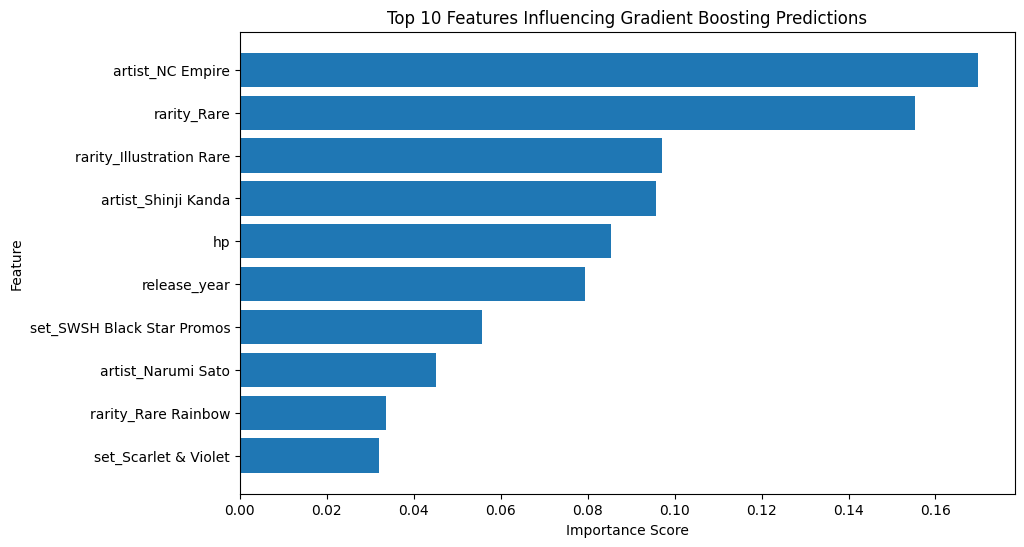

In [ ]:
import matplotlib.pyplot as plt

# Top 10 feature importance visualization

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 10 Features Influencing Gradient Boosting Predictions")

plt.gca().invert_yaxis()

plt.show()

### Observations

The feature importance visualization shows the top features used by the Gradient Boosting model when predicting Pokémon card market prices.

The graph highlights that artist-related features and rarity categories have the strongest influence on predictions. In particular, `artist_NC Empire`, `rarity_Rare`, and `rarity_Illustration Rare` were among the most important features.

Other important features included:
- HP
- Release year
- Specific card sets
- Additional artist categories

This supports the findings from the EDA stage that rarity and collectible characteristics are important factors when estimating card value.


From the client's perspective, the results provide insight into what characteristics may affect card value. Collectible shops can focus on factors such as rarity, artwork, and specific sets when evaluating cards.The results also show that value is not determined only by gameplay statistics. Collector interest and artwork-related factors appear to play an important role.


From a data science perspective, feature importance helps explain how the model is making predictions. However, these values represent model reliance rather than direct cause-and-effect relationships. The high importance of specific artists may indicate that the model is learning patterns associated with certain artists, but it does not necessarily mean the artist alone causes higher prices.

This suggests future improvements could include creating broader artist features or adding additional market-related information to improve generalization.

## Final Model Selection



Based on the evaluation results, Gradient Boosting was selected as the final model because it provided a balanced performance across evaluation metrics and was able to capture complex relationships between card characteristics and market price. Random Forest achieved a slightly lower MAE, but Gradient Boosting produced the lowest RMSE and showed strong predictive ability.

Although Linear Regression provided an interpretable baseline, Pokémon card pricing depends on complex interactions between rarity, set, and other collectible features. Gradient Boosting was better suited for this problem because it can model these relationships more effectively.

### Final Project Reflection

The final model shows that predicting Pokémon card prices is challenging because collectible value depends on many factors that are not fully captured in the dataset. Features such as rarity, set information, and certain artist categories were more useful than gameplay features like HP.

Although the model does not perfectly predict market prices, it demonstrates how machine learning can support collectible pricing decisions by identifying patterns across many card characteristics.

From the client's perspective, this model could be used as a supporting tool to estimate card value and identify cards that may require further review. It should not replace human judgement because factors such as card condition, popularity, and current market trends are not included in the dataset.

Gradient Boosting was selected as the final model because it provided a balanced performance across evaluation metrics and captured complex relationships between card characteristics and market price. Random Forest achieved a slightly lower MAE, but Gradient Boosting produced the lowest RMSE, showing stronger overall prediction consistency.

# Executive Summary

This project explores whether Pokémon card market value can be predicted using card characteristics such as rarity, artist, set information, type, HP, and release date. The goal is to understand which features contribute most to card prices and create a model that can estimate the expected market value of individual cards.

The exploratory analysis showed that Pokémon card prices are highly influenced by collectible factors rather than gameplay statistics alone. Rarity, artist information, and set-related features showed stronger relationships with market value, while features such as HP had limited predictive value. The dataset also contained a highly uneven price distribution, where most cards had lower values and a small number of expensive cards created a large difference in price.

Because the objective was to predict a continuous value (market price in USD), this problem was approached as a supervised regression task. Multiple regression models were tested, including Linear Regression, Random Forest Regression, and Gradient Boosting. Gradient Boosting was selected as the final model because it provided strong overall performance and captured complex relationships between card features.

The final model provides insight into the factors that influence Pokémon card prices and demonstrates how machine learning can support collectible market analysis. While the model cannot replace real market evaluation, it provides a data-driven estimate that can help collectors and sellers better understand pricing patterns.

## Limitations

Although the model was able to identify patterns related to Pokémon card value, there are several limitations to consider. The dataset only represents available card information and market prices at the time of collection. Pokémon card prices can change over time because of demand, competitive popularity, new releases, and collector trends. A model trained on historical data may not fully capture future market changes.

The dataset also contains limited information about external factors that influence collector value, such as tournament performance, player popularity, print quantity, card condition, and market demand. Including these factors could improve future predictions.
high value cards create a strong price imbalance because a small number of rare cards have much higher prices than most cards. Future work could explore additional transformations, larger datasets, or specialized approaches for handling extreme price differences.

lastly the dataset size limits the complexity of the conclusions that can be made. With only 1,000 cards, the model may not fully represent the larger Pokémon card market. A larger dataset containing more historical sales information would allow for more reliable predictions.


#AI Acknowledgement



AI tools were used during the development of this project for debugging code errors, writing code most of it, explaining results then i worked on explanations and observations.
The analysis, dataset decisions, feature engineering choices, and interpretation of results were completed and evaluated by me. AI assistance was used as a support tool to help explain concepts  and troubleshoot code issues.

# References



1. IBM. "Supervised vs. Unsupervised Learning."  
https://www.ibm.com/think/topics/supervised-vs-unsupervised-learning

2. Shahzad, N. "Supervised Machine Learning: Classification and Regression."  
https://medium.com/@nimrashahzadisa064/supervised-machine-learning-classification-and-regression-c145129225f8

3. APXML. "Understanding Regression Problems in Machine Learning."  
https://apxml.com/courses/introduction-to-machine-learning/chapter-3-supervised-learning-regression/understanding-regression-problems

5. GeeksforGeeks. "Regression in Machine Learning."  
https://www.geeksforgeeks.org/machine-learning/regression-in-machine-learning/

6. Statistics By Jim. "Root Mean Square Error (RMSE)."  
https://statisticsbyjim.com/regression/root-mean-square-error-rmse/

7. ScienceDirect Topics. "Mean Absolute Error."  
https://www.sciencedirect.com/topics/engineering/mean-absolute-error

9. GeeksforGeeks. "Linear Regression in Machine Learning."  
https://www.geeksforgeeks.org/machine-learning/ml-linear-regression/

10. GeeksforGeeks. "Random Forest Regression in Python."  
https://www.geeksforgeeks.org/machine-learning/random-forest-regression-in-python/

11. IBM. "Gradient Boosting."  
https://www.ibm.com/think/topics/gradient-boosting

In [ ]:
model_df.to_csv("pokemon_cards.csv", index=False)